In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torch.utils.data import DataLoader
from typing import List

In [2]:
folder_path = "/content/drive/MyDrive/Colab Notebooks"

In [3]:
RED = "\033[31;1m"
GREEN = "\033[32;1m"
YELLOW = "\033[33;1m"
BLUE = "\033[34;1m"
PURPLE = "\033[35;1m"
CYAN = "\033[36;1m"
WHITE = "\033[37;1m"
ORANGE = "\033[38;5;208m"
RESET = "\033[0;0m"

In [4]:
#Setting Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

Using Device: cuda


In [5]:
#Data Transformation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [6]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
#Defining the CNN Architecture
class CatDogCNN(nn.Module):
    def __init__(self, num_classes=2) -> None:
        super(CatDogCNN, self).__init__()

        #First Convolutional Block
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        #Second Convolutional Block
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        #Third Convolutional Block
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        #Fourth Convolutional Block
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        #Fifth Convolutional Block
        self.conv5 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        #Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        #Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)

        return x

In [8]:
#Training Function
def train_model(model, train_loader, val_loader, num_epochs=50, learning_rate=0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_val_acc = 0.0
    patience = 7
    patience_counter = 0

    for epoch in range(0, num_epochs):
      #Training Phase
      model.train()
      running_loss = 0.0
      correct_train = 0
      total_train = 0

      for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += target.size(0)
        correct_train += (predicted == target).sum().item()

        if batch_idx % 100 == 0:
          print(f"{BLUE} Epoch {epoch+1}/{num_epochs}, Batch {batch_idx}, Loss: {loss.item():.4f}")

      #Validation Phase
      model.eval()
      val_loss = 0.0
      correct_val = 0
      total_val = 0

      with torch.no_grad():
        for data, target in val_loader:
          data, target = data.to(device), target.to(device)
          outputs = model(data)
          loss = criterion(outputs, target)

          val_loss += loss.item()
          _, predicted = torch.max(outputs.data, 1)
          total_val += target.size(0)
          correct_val += (predicted == target).sum().item()

      #Calculating Metrics
      train_loss = running_loss / len(train_loader)
      val_loss = val_loss / len(val_loader)
      train_acc = 100 * correct_train / total_train
      val_acc = 100 * correct_val / total_val

      train_losses.append(train_loss)
      val_losses.append(val_loss)
      train_accuracies.append(train_acc)
      val_accuracies.append(val_acc)

      print(f"{BLUE}Epoch {epoch+1}/{num_epochs}:")
      print(f"{ORANGE}Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")
      print(f"{RED}Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.2f}%")
      print(f"{PURPLE}Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
      print(f"{YELLOW}", "-" * 50)

      #Saving the best model
      if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc,
            "train_acc": train_acc,
        }, f"{folder_path}/best_cat_dog_model.pth")
        print(f"{GREEN} New best model saved with validation accuracy: {val_acc:.2f}%")
        patience_counter = 0
      else:
        patience_counter += 1

      #Early stopping
      if patience_counter >= patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

      scheduler.step()

    return train_losses, val_losses, train_accuracies, val_accuracies

In [9]:
def plot_training_accuracies(train_losses, val_losses, train_accuracies, val_accuracies):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

  ax1.plot(train_losses, label="Training Loss", color="blue")
  ax1.plot(val_losses, label="Validation Loss", color="red")
  ax1.set_title("Training and Validation Loss")
  ax1.set_xlabel("Epochs")
  ax1.set_ylabel("Loss")
  ax1.legend()
  ax1.grid(visible=True)

  ax2.plot(train_accuracies, label="Training Accuracy", color="blue")
  ax2.plot(val_accuracies, label="Validation Accuracy", color="red")
  ax2.set_title("Training and Validation Accuracy")
  ax2.set_xlabel("Epochs")
  ax2.set_ylabel("Accuracy (%)")
  ax2.legend()
  ax2.grid(visible=True)

  plt.tight_layout()
  plt.savefig("Training_history.png", dpi=300, bbox_inches="tight")
  plt.show()

In [10]:
from torch._prims_common import check
#Single Image Prediction

def predict_single_image(image_path, model_path=f"{folder_path}/best_cat_dog_model.pth", display=True):
    #Loading the model
    model = CatDogCNN(num_classes=2).to(device)
    checkpoint = torch.load(model_path, map_location=device)

    #Handle both old and new checkpoints format
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
      model.load_state_dict(checkpoint)

    model.eval()

    #Naming Clases
    classes = ["cats", "dogs"]

    #Load and Transform the Image
    image = Image.open(image_path).convert("RGB")
    original_image = image.copy()

    #Applying the same transformation for validation
    image_tensor = val_transform(image).unsqueeze(0).to(device)

    #Making prediction
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = classes[predicted.item()]
    confidence_score = confidence.item() * 100

    #Displaying result
    if display:
      plt.figure(figsize=(10, 6))
      plt.imshow(original_image)
      plt.axis("off")
      plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence_score:.2f}%", fontsize=16, fontweight="bold")
      plt.tight_layout()
      plt.show()

    return predicted_class, confidence_score


In [11]:
def predict_multiple_images(image_paths, model_path=f"{folder_path}/best_cat_dog_model.pth"):


  #Loading the model
  model = CatDogCNN(num_classes=2).to(device)
  checkpoint = torch.load(model_path, map_location=device)

  #Handling both old and new checkpoints format
  if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
      model.load_state_dict(checkpoint["model_state_dict"])
  else:
    model.load_state_dict(checkpoint)

  model.eval()

  #Naming Clases
  classes = ["cats", "dogs"]

  results = []

  print(f"{BLUE}\nProcessing {len(image_paths)} images...\n")

  for img_path in image_paths:
    try:
      image = Image.open(img_path).convert("RGB")
      image_tensor = val_transform(image).unsqueeze(0).to(device)

      with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

      predicted_class = classes[predicted.item()]
      confidence_score = confidence.item() * 100

      results.append((img_path, predicted_class, confidence_score))
      print(f"{GREEN} {img_path}:{predicted_class} {confidence_score:.2f}%")
    except Exception as e:
      print(f"{RED}Error processing {img_path}: {str(e)}")
      results.append((img_path, "Error", 0.0))

  return results

In [12]:
#Loaders and Running Code
train_mode = True

In [13]:
def load_datasets(train_dir, val_dir, batch_size=32):
  train_dataset = datasets.ImageFolder(
      root=train_dir,
      transform=train_transform
  )

  val_dataset = datasets.ImageFolder(
      root=val_dir,
      transform=val_transform
  )

  train_loader = DataLoader(
      train_dataset,
      batch_size=batch_size,
      shuffle=True,
      num_workers=4,
      pin_memory=True
  )

  val_loader = DataLoader(
      val_dataset,
      batch_size=batch_size,
      shuffle=False,
      num_workers=4,
      pin_memory=True
  )

  classes = train_dataset.classes

  return train_loader, val_loader, classes

In [14]:
if train_mode:
  train_dir = "/content/drive/MyDrive/Colab Notebooks/CNN/train"
  val_dir = "/content/drive/MyDrive/Colab Notebooks/CNN/validation"

  batch_size = 32
  num_epochs = 50
  learning_rate = 0.001

  print(f"{PURPLE}Loading datasets...")
  train_loader, val_loader, classes = load_datasets(train_dir, val_dir, batch_size)
  print(f"{BLUE}Classes: {classes}")
  print(f"{CYAN}Training samples: {len(train_loader.dataset)}")
  print(f"Validation Samples:  {len(val_loader.dataset)}")

  model = CatDogCNN(num_classes=len(classes)).to(device)
  print(f"{ORANGE}Model initiatied with: {sum(p.numel() for p in model.parameters()):,} parameters")

  print(f"{GREEN}\nStarting training...")
  train_losses, val_losses, train_accuracies, val_accuracies = train_model(
      model, train_loader, val_loader, num_epochs, learning_rate
  )

Loading datasets...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Classes: ['cats', 'dogs']
Training samples: 2010
Validation Samples:  1000
Model initiatied with: 1,702,402 parameters

Starting training...
 Epoch 1/50, Batch 0, Loss: 0.7536
Epoch 1/50:
Train Loss: 0.7069, Train Accuracy: 53.83%
Val Loss: 0.6476, Val Accuracy: 60.30%
Learning Rate: 0.001000
 --------------------------------------------------
 New best model saved with validation accuracy: 60.30%
 Epoch 2/50, Batch 0, Loss: 0.6821
Epoch 2/50:
Train Loss: 0.6711, Train Accuracy: 58.31%
Val Loss: 0.6675, Val Accuracy: 60.60%
Learning Rate: 0.001000
 --------------------------------------------------
 New best model saved with validation accuracy: 60.60%
 Epoch 3/50, Batch 0, Loss: 0.6630
Epoch 3/50:
Train Loss: 0.6685, Train Accuracy: 59.70%
Val Loss: 0.6449, Val Accuracy: 61.90%
Learning Rate: 0.001000
 --------------------------------------------------
 New best model saved with validation accuracy: 61.90%
 Epoch 4/50, Batch 0, Loss: 0.6065
Epoch 4/50:
Train Loss: 0.6624, Train Accura

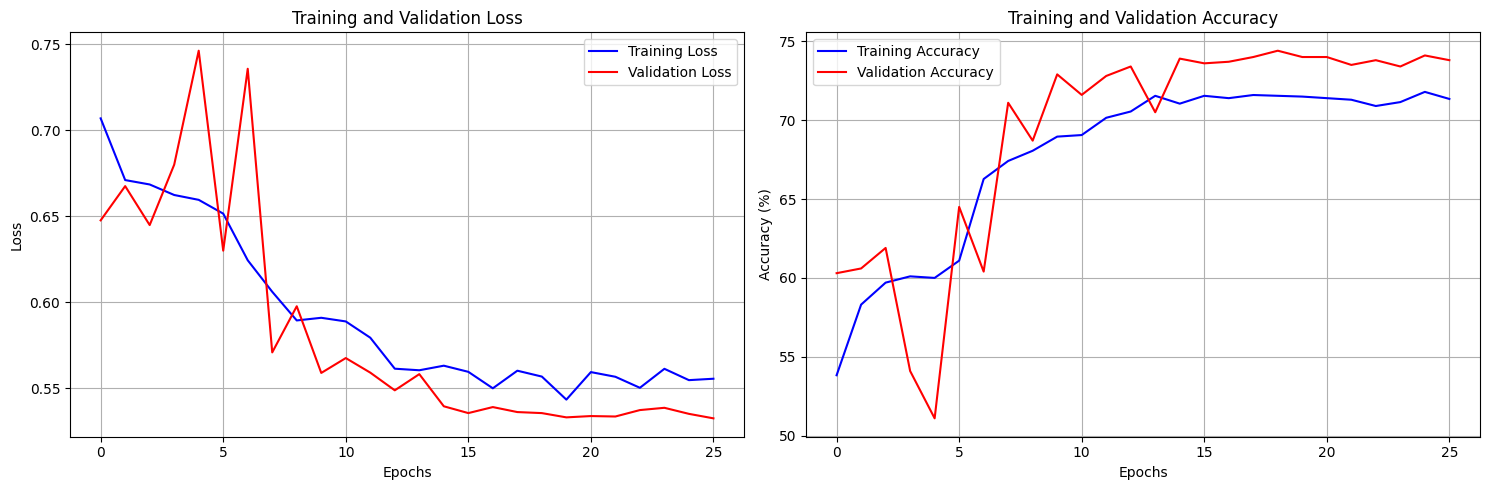

In [15]:
if train_mode:
  plot_training_accuracies(train_losses, val_losses, train_accuracies, val_accuracies)

In [16]:
if train_mode:

  path = "/content/drive/MyDrive/Colab Notebooks/best_cat_dog_model.pth"
  checkpoint = torch.load(path)
  model.load_state_dict(checkpoint["model_state_dict"])

In [ ]:
predict_single_image(
    image_path=""
    model_path=""
    display=True
)